# Temporary Market Impact Parameter Estimation

This notebook estimates temporary market impact on a trade-count clock.

- Collapse multi-hit fills into parent trades by `(exchange, floored timestamp, side)`.
- Compute signed markouts: `y = sgn * (p_fwd / p - 1)`, where `p_fwd` is `M` trades ahead.
- Fit square-root and power-law impact forms by date and volume quantile cohort.

In [42]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import pandas as pd

from impact_config import ImpactConfig
from io_t import find_trade_files, read_trades_parquet, explore_trades
from impact_core import collapse_multihit_trades, run_exchange_and_pooled, robustness_sweep, infer_side_signs, add_markouts, trim_outliers_and_bin
from plots import plot_fit, save_figure

## Data

In [36]:
repo_root = Path('..').resolve()
outdir = repo_root / 'outputs'
outdir.mkdir(parents=True, exist_ok=True)
figdir = outdir / 'figures'
figdir.mkdir(parents=True, exist_ok=True)

cfg = ImpactConfig(M=50, ts_floor='1ms', min_n=1000)
files = find_trade_files(repo_root)

In [37]:
demo = read_trades_parquet(files[0], max_rows=26000000 , sample_frac=None)
print('One-file demo shape:', demo.shape)
explore_trades(demo)

One-file demo shape: (25867658, 5)
rows=25,867,658
exchanges=4
date span=2025-05-01 00:00:00.079973968+00:00 -> 2025-05-31 23:59:56.938408236+00:00
top exchanges:
exchange
BINANCE     17559275
OKX          5462807
GATE_IO      2581544
COINBASE      264032
Name: count, dtype: Int64
side labels:
side
B    13272956
A    12594702
Name: count, dtype: Int64
qty quantiles:
0.5000      0.037000
0.9000      4.790000
0.9900     38.757080
0.9975     83.256431
0.9990    136.523455
Name: qty, dtype: float64
price quantiles:
0.00    141.41
0.50    173.63
0.90    181.64
0.99    186.17
1.00    187.71
Name: price, dtype: float64


In [38]:
if files:
    chunks = [read_trades_parquet(f, cfg.max_rows_per_file, cfg.sample_frac) for f in files]
    trades = pd.concat(chunks, ignore_index=True)
else:
    n = 30000
    trades = pd.DataFrame({
        'ts': pd.date_range('2024-01-01', periods=n, freq='ms', tz='UTC'),
        'exchange': ['SYNX' if i % 2 == 0 else 'SYNY' for i in range(n)],
        'side': ['BUY' if i % 3 == 0 else 'SELL' for i in range(n)],
        'qty': 1 + (pd.Series(range(n)) % 150).to_numpy(),
        'price': 100 + (pd.Series(range(n)).to_numpy() * 1e-4),
    })

parents = collapse_multihit_trades(trades, cfg.ts_floor)
results = run_exchange_and_pooled(parents, cfg)
print('Parent rows:', len(parents))
print('Result rows:', len(results))
results.head()

Parent rows: 7508531
Result rows: 400


,label,date,qbin,mu0,mu0_se_hac,n,r2,mu1,mu2,mu1_se,mu2_se,success,cost
0,EX:BINANCE,2025-05-04,Q0.8000_0.9000,0.000027,0.000001,15545,0.054010,4.845939e-05,0.275598,0.000013,0.102591,True,0.001346
1,EX:BINANCE,2025-05-04,Q0.9000_0.9500,0.000020,0.000001,6908,0.072529,9.015639e-05,0.068068,0.000074,0.232569,True,0.000575
2,EX:BINANCE,2025-05-04,Q0.9500_0.9700,0.000013,0.000001,2560,0.051574,2.208206e-06,0.930122,0.000007,0.805830,True,0.000214
3,EX:BINANCE,2025-05-04,Q0.9700_0.9900,0.000011,0.000001,2461,0.065897,6.968291e-05,0.099262,0.000126,0.399217,True,0.000207
4,EX:BINANCE,2025-05-04,Q0.9900_0.9975,0.000008,0.000001,1033,0.063288,6.377436e-07,0.988905,0.000002,0.689114,True,0.000092


In [ ]:
results.to_parquet(outdir / 'impact_results.parquet', index=False)
results.to_csv(outdir / 'impact_results.csv', index=False)

Saved base results tables.


In [43]:
# Diagnostics: side->sign mapping stability
sign_ref_M = getattr(cfg, "sign_ref_M", 1)
side_map_mode = getattr(cfg, "side_map_mode", "infer")

for ex, g in parents.groupby("exchange", observed=True):
    try:
        m = infer_side_signs(g, sign_ref_M, mode=side_map_mode)
    except TypeError:
        # older impact_core.py without `mode=`
        m = infer_side_signs(g, sign_ref_M)

    mk1 = add_markouts(g, 1, m)
    print(
        f"{ex}: {m} | mean(y,M=1)={mk1['y'].mean(): .3e} | "
        f"neg_frac(y,M=1)={(mk1['y']<0).mean():.3f}"
    )

BINANCE: {'A': 1, 'B': -1} | mean(y,M=1)= 1.594e-06 | neg_frac(y,M=1)=0.304
COINBASE: {'A': -1, 'B': 1} | mean(y,M=1)= 5.096e-05 | neg_frac(y,M=1)=0.332
GATE_IO: {'B': 1, 'A': -1} | mean(y,M=1)= 3.853e-05 | neg_frac(y,M=1)=0.175
OKX: {'B': 1, 'A': -1} | mean(y,M=1)= 1.678e-05 | neg_frac(y,M=1)=0.242


In [44]:
eps = 1e-4
mu2_lb = (results["mu2"] <= eps)
mu2_ub = (results["mu2"] >= 1 - eps)

print("mu2 bound-hit rates (baseline):")
display(
    results.assign(mu2_lb=mu2_lb, mu2_ub=mu2_ub)
           .groupby("label", observed=True)[["mu2_lb","mu2_ub"]]
           .mean()
           .sort_index()
)

print("mu2 summary by label (baseline):")
display(results.groupby("label", observed=True)["mu2"].describe())

mu2 bound-hit rates (baseline):


,mu2_lb,mu2_ub
label,,
ALL,0.271429,0.028571
EX:BINANCE,0.200000,0.025000
EX:COINBASE,0.500000,0.250000
EX:GATE_IO,0.380952,0.083333
EX:OKX,0.356061,0.053030


mu2 summary by label (baseline):


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ALL,140.0,0.243855,0.310880,0.000001,0.000060,0.100276,0.380029,0.999999
EX:BINANCE,40.0,0.337075,0.316439,0.000001,0.071275,0.249255,0.550270,0.999999
EX:COINBASE,4.0,0.498211,0.575290,0.000001,0.000002,0.496422,0.994632,0.999999
EX:GATE_IO,84.0,0.304032,0.394616,0.000001,0.000001,0.071092,0.630877,0.999999
EX:OKX,132.0,0.273082,0.359793,0.000001,0.000006,0.050413,0.461485,0.999999


Saved figure: C:\Users\Owner\Box\Winter26\QTS\qts\HW7_impact\outputs\figures\fit_EX_BINANCE_2025-05-04_Q0_8000_0_9000.png


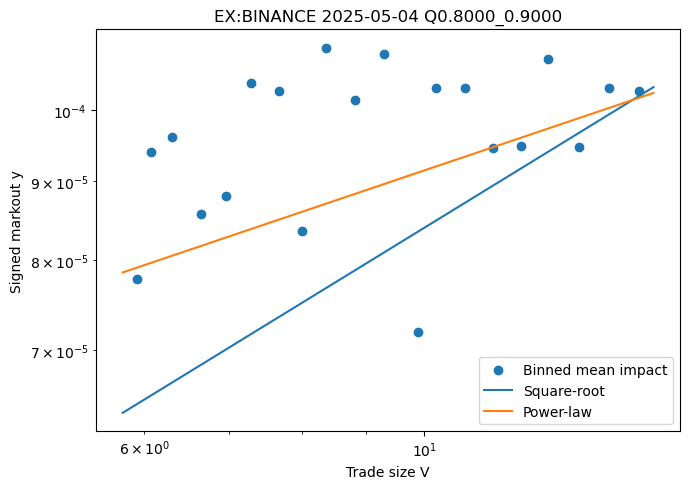

In [45]:
if not parents.empty and not results.empty:
    side_map = infer_side_signs(parents, cfg.M)
    markouts = add_markouts(parents, cfg.M, side_map)
    binned = trim_outliers_and_bin(markouts, cfg.q_outlier, cfg.q_bins)
    sample = results.iloc[0]
    dplot = binned[binned['qbin'] == sample['qbin']]
    if not dplot.empty:
        fig = plot_fit(dplot, sample['mu0'], sample['mu1'], sample['mu2'], f"{sample['label']} {sample['date']} {sample['qbin']}")
        fig_path = save_figure(fig, figdir, f"fit_{sample['label']}_{sample['date']}_{sample['qbin']}")
        print('Saved figure:', fig_path)

## Diagnostics

In [46]:
rob = robustness_sweep(parents, cfg)
rob.to_parquet(outdir / 'impact_robustness.parquet', index=False)
rob.to_csv(outdir / 'impact_robustness.csv', index=False)
print('Robustness rows:', len(rob))
if not rob.empty:
    summary = rob.groupby(['label','M','q_outlier'], observed=True)['mu2'].median().reset_index()
    summary = summary.sort_values(['label','M','q_outlier'])
    summary.head(20)

Robustness rows: 6937


In [47]:
eps = 1e-4
rob2 = rob.assign(mu2_lb=(rob["mu2"]<=eps), mu2_ub=(rob["mu2"]>=1-eps))
display(
    rob2.groupby(["label","M","q_outlier"], observed=True)[["mu2_lb","mu2_ub"]].mean()
        .reset_index()
        .sort_values(["label","M","q_outlier"])
        .head(30)
)

,label,M,q_outlier,mu2_lb,mu2_ub
0,ALL,1,0.9950,0.161972,0.056338
1,ALL,1,0.9975,0.142857,0.042857
2,ALL,1,0.9990,0.164286,0.035714
3,ALL,5,0.9950,0.216216,0.027027
4,ALL,5,0.9975,0.171429,0.007143
5,ALL,5,0.9990,0.171429,0.007143
6,ALL,10,0.9950,0.185484,0.008065
7,ALL,10,0.9975,0.207143,0.007143
8,ALL,10,0.9990,0.207143,0.007143
9,ALL,25,0.9950,0.204225,0.000000


In [49]:
import importlib
import impact_config, impact_core

importlib.reload(impact_config)
importlib.reload(impact_core)

from impact_config import ImpactConfig
from impact_core import infer_side_signs, add_markouts, trim_outliers_and_bin

WindowsPath('C:/Users/Owner/Box/Winter26/QTS/qts/HW7_impact/outputs/figures/fit_daily_EX_BINANCE_2025-05-04.png')

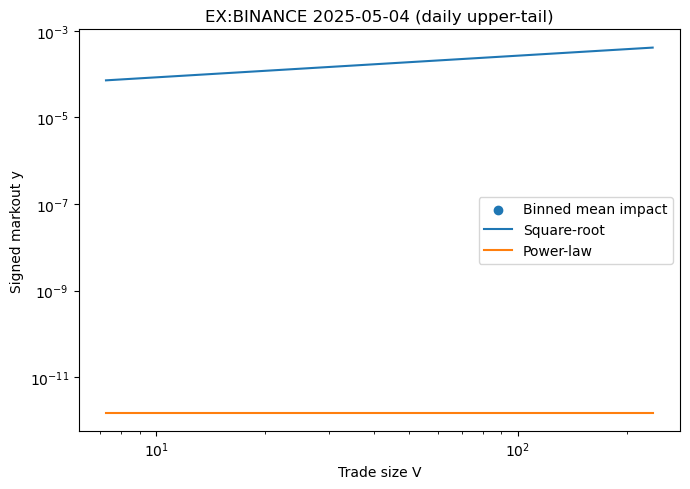

In [51]:
# Plot on a full-day dataset (all qbins combined) for stability
sample_row = results.iloc[0]
lab = sample_row["label"]
day = sample_row["date"]

if lab == "ALL":
    df_lab = parents
else:
    ex = lab.replace("EX:", "")
    df_lab = parents[parents["exchange"] == ex]

m = infer_side_signs(df_lab, sign_ref_M, mode=side_map_mode)
mk = add_markouts(df_lab, cfg.M, m)
mk = mk[mk["ts"].dt.date == day]
mk = trim_outliers_and_bin(mk, cfg.q_outlier, cfg.q_bins)

# Fit daily exponent on mk (all qbins) and plot against mk
from impact_core import fit_power_exponent_binned
pwr_day = fit_power_exponent_binned(mk)

fig = plot_fit(mk, sample_row["mu0"], pwr_day["mu1"], pwr_day["mu2"], f"{lab} {day} (daily upper-tail)")
save_figure(fig, figdir, f"fit_daily_{lab}_{day}")